
# 04 — Modeling

This notebook evaluates two simple modeling baselines for the Quora duplicate-question task:

- **Logistic Regression** on horizontally concatenated **TF-IDF vectors** of the two questions;
- **XGBoost** on the engineered pair-level feature table created in the previous notebook.

The primary metric is **log loss (cross-entropy)**, because the assignment asks the models to predict duplicate probabilities rather than only hard labels.

The modeling stage is intentionally kept simple and interpretable. The goal is to show how much signal can already be extracted from sparse lexical vectors and from compact engineered similarity features before moving to heavier neural architectures.


In [1]:

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

%load_ext autoreload
%autoreload 2


def _find_project_root() -> Path:
    cwd = Path.cwd().resolve()
    candidates = [cwd, cwd.parent]
    for candidate in candidates:
        if (candidate / "project_bootstrap.py").exists():
            return candidate
    return cwd


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from project_bootstrap import setup_project

PROJECT_ROOT = setup_project()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 120)


In [2]:

import importlib.util

has_xgboost = importlib.util.find_spec("xgboost") is not None
has_torch = importlib.util.find_spec("torch") is not None

if has_torch:
    import torch
else:
    torch = None

from modeling import (
    baseline_prior,
    build_model_comparison_frame,
    fit_tfidf_concat,
    load_feature_table,
    load_preprocessed_dataset,
    make_split,
    select_numeric_feature_columns,
    train_logreg,
    train_xgboost,
)


In [4]:

SAMPLE_N = None
RANDOM_STATE = 42
TEST_SIZE = 0.2

RUN_LOGREG = True
RUN_XGBOOST = has_xgboost
USE_XGB_GPU = bool(has_torch and torch.cuda.is_available())

TFIDF_MAX_FEATURES = 150000
TFIDF_NGRAM_RANGE = (1, 2)
TFIDF_MIN_DF = 2

XGB_PARAMS = {
    "n_estimators": 600,
    "learning_rate": 0.05,
    "max_depth": 6,
    "subsample": 0.85,
    "colsample_bytree": 0.85,
}



## 1. Load the preprocessed text and the engineered feature table

The modeling stage consumes two artifacts produced earlier in the project:

- the **preprocessed dataset** with cleaned text columns used for vectorization;
- the **engineered pair-feature table** used for tree-based modeling.

If BERT similarity features were generated in the feature-engineering notebook and saved separately, the helper functions merge them automatically into the final feature table.


In [5]:

text_df = load_preprocessed_dataset(PROJECT_ROOT)
feature_df = load_feature_table(PROJECT_ROOT)

if SAMPLE_N is not None and SAMPLE_N < len(text_df):
    sampled_idx = text_df.sample(SAMPLE_N, random_state=RANDOM_STATE).index
    text_df = text_df.loc[sampled_idx].reset_index(drop=True)
    feature_df = feature_df.loc[sampled_idx].reset_index(drop=True)
else:
    text_df = text_df.reset_index(drop=True)
    feature_df = feature_df.reset_index(drop=True)

assert len(text_df) == len(feature_df), "Text and feature tables must have the same number of rows."
assert text_df["is_duplicate"].equals(feature_df["is_duplicate"]), "Targets must stay aligned."

feature_cols = select_numeric_feature_columns(feature_df)
has_bert_features = any(col.startswith("bert_") for col in feature_cols)

summary_df = pd.DataFrame(
    {
        "table": ["text_df", "feature_df"],
        "rows": [len(text_df), len(feature_df)],
        "columns": [text_df.shape[1], feature_df.shape[1]],
    }
)

display(summary_df)
print(f"Numeric engineered features used by XGBoost: {len(feature_cols)}")
print(f"BERT-derived engineered features present: {has_bert_features}")


,table,rows,columns
0,text_df,323432,10
1,feature_df,323432,40


Numeric engineered features used by XGBoost: 38
BERT-derived engineered features present: True



## 2. Shared train/validation split and prior baseline

A single stratified split is reused across all models so that the comparisons remain fair. A prior-probability baseline is also computed to show the minimum performance level that any trained model should clearly beat.


In [6]:

y = text_df["is_duplicate"].to_numpy()
split = make_split(y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=True)

results = []
baseline_metrics = baseline_prior(split.y_train, split.y_val)
results.append(("baseline_prior", baseline_metrics))

pd.DataFrame([{"model": "baseline_prior", **baseline_metrics}])


,model,log_loss,roc_auc
0,baseline_prior,0.658525,0.5



## 3. Logistic Regression on concatenated TF-IDF vectors

This model follows the simple approach suggested in the assignment: each question is converted into a TF-IDF vector, and the two vectors are **concatenated horizontally**. The resulting sparse representation is then passed to Logistic Regression, which directly predicts the probability of the pair being a duplicate.

This baseline is valuable because it is easy to train, easy to interpret, and provides a strong reference point for more complex models.


In [7]:

logreg_metrics = None

if RUN_LOGREG:
    q1_source = text_df["q1_classic"] if "q1_classic" in text_df.columns else text_df["question1"].fillna("")
    q2_source = text_df["q2_classic"] if "q2_classic" in text_df.columns else text_df["question2"].fillna("")

    vectorizer, X_train_lr, X_val_lr = fit_tfidf_concat(
        q1_source.iloc[split.idx_train],
        q2_source.iloc[split.idx_train],
        q1_source.iloc[split.idx_val],
        q2_source.iloc[split.idx_val],
        max_features=TFIDF_MAX_FEATURES,
        ngram_range=TFIDF_NGRAM_RANGE,
        min_df=TFIDF_MIN_DF,
    )

    logreg_model, logreg_metrics, logreg_pred = train_logreg(
        X_train_lr,
        split.y_train,
        X_val_lr,
        split.y_val,
        C=2.0,
        max_iter=400,
    )
    results.append(("logreg_tfidf_concat", logreg_metrics))

    display(pd.DataFrame([{"model": "logreg_tfidf_concat", **logreg_metrics}]))
    print(f"TF-IDF vocabulary size: {len(vectorizer.vocabulary_):,}")


,model,log_loss,roc_auc
0,logreg_tfidf_concat,0.471449,0.831999


TF-IDF vocabulary size: 150,000



**Interpretation.**

This experiment shows how far a straightforward lexical baseline can go when the two questions are represented as concatenated sparse vectors. Good performance here means that duplicate detection already benefits from shared vocabulary, repeated key phrases, and common local n-gram structure.

At the same time, this model still treats meaning mostly through surface-form statistics. That makes it a useful comparison point for the feature-based XGBoost model, which can combine overlap, fuzzy, sparse, and semantic signals in a nonlinear way.



## 4. XGBoost on engineered similarity features

The second model is trained on the compact feature table built in the previous notebook. This table combines lexical overlap, fuzzy matching, sparse-vector similarities, and optionally BERT-derived semantic distances.

XGBoost is well suited here because it can model nonlinear interactions between these heterogeneous signals without requiring a fully neural architecture.


In [8]:

xgb_metrics = None
xgb_feature_importance = None

if RUN_XGBOOST:
    X_all = feature_df[feature_cols].astype(np.float32)
    X_train_xgb = X_all.iloc[split.idx_train]
    X_val_xgb = X_all.iloc[split.idx_val]

    xgb_model, xgb_metrics, xgb_pred = train_xgboost(
        X_train_xgb,
        split.y_train,
        X_val_xgb,
        split.y_val,
        params=XGB_PARAMS,
        use_gpu=USE_XGB_GPU,
    )
    results.append(("xgboost_engineered_features", xgb_metrics))

    display(pd.DataFrame([{"model": "xgboost_engineered_features", **xgb_metrics}]))

    xgb_feature_importance = (
        pd.Series(xgb_model.feature_importances_, index=feature_cols)
        .sort_values(ascending=False)
        .head(20)
        .rename_axis("feature")
        .reset_index(name="importance")
    )


C:\Users\Dmity\.conda\envs\quora-bert\Lib\site-packages\xgboost\core.py:751: UserWarning: [21:30:49] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


,model,log_loss,roc_auc
0,xgboost_engineered_features,0.385057,0.894665


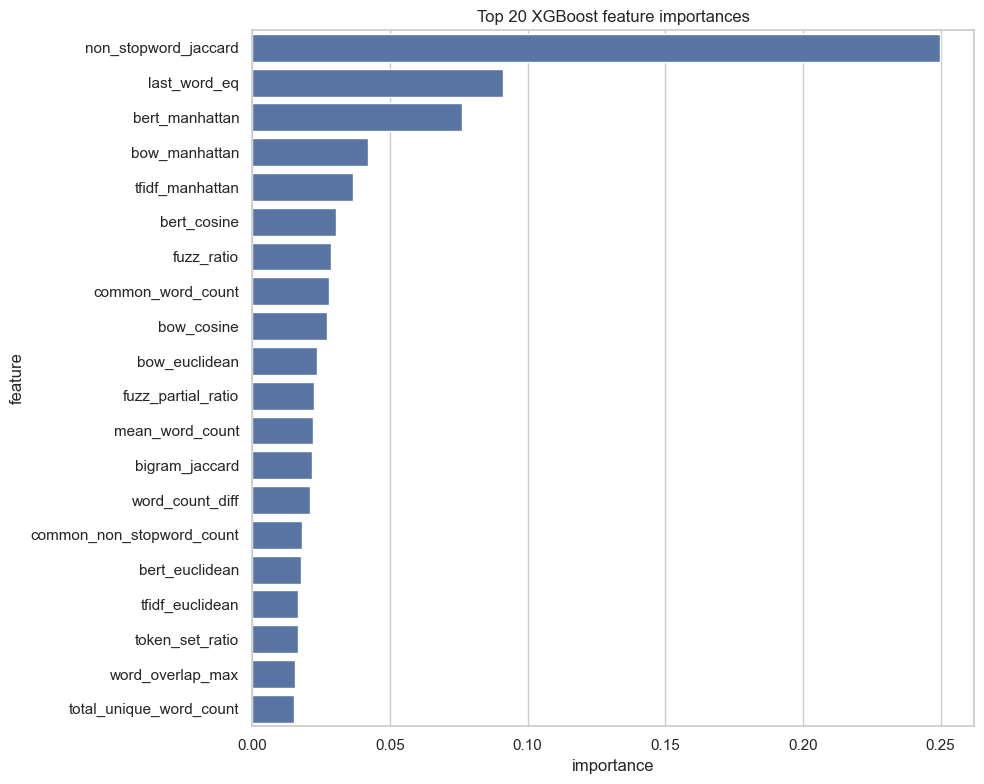

In [9]:

if xgb_feature_importance is not None:
    plt.figure(figsize=(10, 8))
    sns.barplot(data=xgb_feature_importance, x="importance", y="feature")
    plt.title("Top 20 XGBoost feature importances")
    plt.tight_layout()
    plt.show()

    xgb_feature_importance.head(10)



**Interpretation.**

The XGBoost experiment evaluates whether pairwise feature engineering provides a stronger signal than the sparse lexical baseline. If this model improves log loss, it indicates that the engineered similarities are not merely descriptive plots from the previous notebook, but genuinely useful predictive features.

The feature-importance ranking also helps verify which groups of signals contribute most to the final decision boundary. In particular, it is useful for checking whether BERT-based semantic features add value on top of lexical and fuzzy overlap features.



## 5. Model comparison

The table below summarizes all evaluated models on the same validation split. Lower **log loss** is better, while higher **ROC AUC** is better.


In [10]:

comparison_df = build_model_comparison_frame(results)
comparison_df


,model,log_loss,roc_auc
0,xgboost_engineered_features,0.385057,0.894665
1,logreg_tfidf_concat,0.471449,0.831999
2,baseline_prior,0.658525,0.500000


In [11]:

comparison_path = REPORTS_DIR / "model_comparison_simple.csv"
comparison_df.to_csv(comparison_path, index=False)
print(f"Saved model comparison to: {comparison_path}")


Saved model comparison to: D:\Git\Quora-project\reports\model_comparison_simple.csv


In [12]:

if not comparison_df.empty:
    best_row = comparison_df.iloc[0]
    best_model_name = best_row["model"]
    best_log_loss = best_row["log_loss"]
    best_auc = best_row["roc_auc"]
    bert_note = "BERT-based engineered features were available to XGBoost." if has_bert_features else "The current feature table did not include saved BERT-based engineered features."

    summary_md = f"""
### Reviewer-oriented summary

- A **prior baseline** was computed first to establish the minimum reference performance for probability prediction.
- **Logistic Regression** was trained on **concatenated TF-IDF vectors** of the two questions, exactly matching the simple sparse-vector approach described in the assignment.
- **XGBoost** was trained on the engineered pair-feature table produced in the previous notebook.
- The best validation result in this run was obtained by **{best_model_name}** with **log loss = {best_log_loss:.4f}** and **ROC AUC = {best_auc:.4f}**.
- {bert_note}

Overall, this notebook demonstrates that the project now contains two clear classical modeling branches: a transparent sparse-text baseline and a nonlinear tree-based model over engineered similarity features.
"""
    display(Markdown(summary_md))



### Reviewer-oriented summary

- A **prior baseline** was computed first to establish the minimum reference performance for probability prediction.
- **Logistic Regression** was trained on **concatenated TF-IDF vectors** of the two questions, exactly matching the simple sparse-vector approach described in the assignment.
- **XGBoost** was trained on the engineered pair-feature table produced in the previous notebook.
- The best validation result in this run was obtained by **xgboost_engineered_features** with **log loss = 0.3851** and **ROC AUC = 0.8947**.
- BERT-based engineered features were available to XGBoost.

Overall, this notebook demonstrates that the project now contains two clear classical modeling branches: a transparent sparse-text baseline and a nonlinear tree-based model over engineered similarity features.
